### `Analytics`

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 

In [5]:
pd.set_option("display.max_columns", 60)

In [6]:
df = pd.read_csv("D:/CODING/Virtual_py/PROJECTS/real_estate_ml/backend/kolkata/kolkata_cleaned_v5.csv")

In [7]:
df.head()

,PREFERENCE,DESCRIPTION,TRANSACT_TYPE,BEDROOM_NUM,AGE,TOTAL_FLOOR,PROP_NAME,PROP_HEADING,SECONDARY_TAGS,TOTAL_LANDMARK_COUNT,BALCONY_NUM,FLOOR_NUM,PRICE_Cr,AREA_SQFT,PRICE_PER_SQFT(INR),OWNTYPE_label,LATITUDE,LONGITUDE,Cooperative Society,Power of Attorney,Other,Leasehold,FACING_LABEL,FACING_label_North,FACING_label_North-East,FACING_label_North-West,FACING_label_Other,FACING_label_South,FACING_label_South-East,FACING_label_South-West,FACING_label_West,FURNISH_LABEL,FURNISH_label_Other,FURNISH_label_Semi-furnished,FURNISH_label_Unfurnished,PROPERTY_type,PROPERTY_TYPE_Independent/Builder Floor,PROPERTY_TYPE_Residential Apartment,PROPERTY_TYPE_Residential Land,CITY_LABELS,CITY_Kolkata East,CITY_Kolkata North,CITY_Kolkata South,CITY_Kolkata West,LANDMARK_DETAILS,CITY_NUM,LOCALITY
0,S,3bhk flat on the second floor of a four-Storey...,1.0,3.0,6,4.0,team taurus kabya,3 BHK Flat in Rajarhat,"['READY TO MOVE', 'RESALE', 'RERA | HIRA']",29.0,2.0,2.0,0.50,1287.0,3885.00,Cooperative Society,22.629509,88.479623,1,0,0,0,East,0,0,0,0,0,0,0,0,Fully furnished,0,0,0,Residential Apartment,0,1,0,Kolkata East,1,0,0,0,"['ReligiousPlace', 'Hospital', 'OfficeComplex'...",28,Rajarhat
1,S,"3bhk, 2 bath, semi-Furnished, 7th floor (Of 15...",1.0,3.0,2,15.0,eden city maheshtala,3 BHK Flat in Maheshtala,"['READY TO MOVE', 'RESALE', 'RERA | HIRA']",8.0,1.0,7.0,0.45,1377.0,3267.97,Cooperative Society,88.210954,22.493402,1,0,0,0,East,0,0,0,0,0,0,0,0,Other,1,0,0,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['MetroStation', 'Shopping', 'Connectivity', '...",27,Maheshtala
2,S,3bhk flat/apartment for sale in baisnabghata b...,1.0,2.0,3,3.0,baisnabghata,2 BHK Flat in Baishnabghata Bye Lane,"['READY TO MOVE', 'RESALE']",48.0,4.0,3.0,0.35,810.0,4320.99,Cooperative Society,22.471111,88.372903,1,0,0,0,South-East,0,0,0,0,0,1,0,0,Other,1,0,0,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['MetroStation', 'ReligiousPlace', 'ATM', 'Hos...",27,Baishnabghata Bye Lane
3,S,This is your chance to own a 3 bhk residential...,1.0,3.0,5,3.0,moana by varada group,3 BHK Flat in Raja SC Mallick ROAD,"['UNDER CONSTRUCTION', 'RESALE']",50.0,1.0,1.0,0.75,1208.0,6208.61,Cooperative Society,22.496720,88.370570,1,0,0,0,East,0,0,0,0,0,0,0,0,Fully furnished,0,0,0,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['ReligiousPlace', 'Hospital', 'Attraction']",27,Raja SC Mallick ROAD
4,S,2bhk flat/apartment for sale in lake gardens c...,1.0,2.0,3,5.0,lake gardens chs,2 BHK Flat in Lake Gardens,"['READY TO MOVE', 'RESALE']",50.0,0.0,0.0,0.50,827.0,6045.95,Cooperative Society,22.505744,88.356716,1,0,0,0,North-West,0,0,1,0,0,0,0,0,Unfurnished,0,0,1,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['MetroStation', 'ReligiousPlace', 'ATM', 'Hos...",27,Lake Gardens


In [4]:
df.columns

Index(['PREFERENCE', 'DESCRIPTION', 'TRANSACT_TYPE', 'BEDROOM_NUM', 'AGE',
       'TOTAL_FLOOR', 'PROP_NAME', 'PROP_HEADING', 'SECONDARY_TAGS',
       'TOTAL_LANDMARK_COUNT', 'BALCONY_NUM', 'FLOOR_NUM', 'PRICE_Cr',
       'AREA_SQFT', 'PRICE_PER_SQFT(INR)', 'OWNTYPE_label', 'LATITUDE',
       'LONGITUDE', 'Cooperative Society', 'Power of Attorney', 'Other',
       'Leasehold', 'FACING_LABEL', 'FACING_label_North',
       'FACING_label_North-East', 'FACING_label_North-West',
       'FACING_label_Other', 'FACING_label_South', 'FACING_label_South-East',
       'FACING_label_South-West', 'FACING_label_West', 'FURNISH_LABEL',
       'FURNISH_label_Other', 'FURNISH_label_Semi-furnished',
       'FURNISH_label_Unfurnished', 'PROPERTY_type',
       'PROPERTY_TYPE_Independent/Builder Floor',
       'PROPERTY_TYPE_Residential Apartment', 'PROPERTY_TYPE_Residential Land',
       'CITY_LABELS', 'CITY_Kolkata East', 'CITY_Kolkata North',
       'CITY_Kolkata South', 'CITY_Kolkata West', 'LANDMARK_D

In [8]:
place_df = df[['LATITUDE',
       'LONGITUDE', 'PRICE_Cr',
       'AREA_SQFT', 'PRICE_PER_SQFT(INR)', 'CITY_LABELS', 'CITY_NUM','LOCALITY']]

In [53]:
# grouped1 = (
#     place_df.groupby("LOCALITY")[["PRICE_Cr", "PRICE_PER_SQFT(INR)", "AREA_SQFT", "LATITUDE", "LONGITUDE",  "CITY_NUM", "CITY_LABELS"]]

#     .mean()
# )
# grouped1.head()

grouped1 = (
    place_df.groupby("LOCALITY").agg({
        "PRICE_Cr": "mean",
        "PRICE_PER_SQFT(INR)": "mean",
        "AREA_SQFT": "mean",
        "LATITUDE": "mean",
        "LONGITUDE": "mean",
        "CITY_NUM": "first",       # keep one representative value
        "CITY_LABELS": "first"     # keep the city label
    })
)

grouped1.head()


,PRICE_Cr,PRICE_PER_SQFT(INR),AREA_SQFT,LATITUDE,LONGITUDE,CITY_NUM,CITY_LABELS
LOCALITY,,,,,,,
5/1B MM Feeder Road.Kolkata-700057,0.380000,4408.350000,862.000000,22.665262,88.371312,26,Kolkata North
AA 1D NEWTOWN,0.650000,5909.090000,1100.000000,22.632687,88.450763,28,Kolkata East
Action Area 1,0.942997,6346.885077,1438.661538,22.576825,88.455485,28,Kolkata East
Action Area 2,1.076459,6825.034068,1513.220339,22.594707,88.462940,28,Kolkata East
Action Area 2B,0.698878,5248.421111,1322.000000,22.608671,88.469523,28,Kolkata East


In [14]:
grouped2 = (
    place_df.groupby('CITY_LABELS')[["PRICE_Cr", "PRICE_PER_SQFT(INR)", "AREA_SQFT", "LATITUDE", "LONGITUDE"]]
    .mean()
    .reset_index()
)
grouped2.head()

,CITY_LABELS,PRICE_Cr,PRICE_PER_SQFT(INR),AREA_SQFT,LATITUDE,LONGITUDE
0,Kolkata Central,1.700500,10545.176000,1620.900000,22.555645,88.370755
1,Kolkata East,0.894630,6238.186785,1367.103129,22.593567,88.465134
2,Kolkata North,0.576423,4710.740508,1078.664008,22.654808,88.416581
3,Kolkata South,0.767576,5722.541090,1229.198276,22.539567,88.285432
4,Kolkata West,0.325716,3362.088070,940.991228,22.696124,88.342354


In [44]:
# import plotly.express as px

# # 1. Reset the index so the index becomes a regular column (e.g., named "Location")
# # grouped1_reset = grouped1.reset_index()

# # 2. Use the new column name for the text parameter
# fig = px.scatter_map(
#     grouped1,
#     lat="LATITUDE", 
#     lon="LONGITUDE", 
#     color="PRICE_PER_SQFT(INR)", 
#     size="AREA_SQFT", 
#     color_continuous_scale=px.colors.cyclical.IceFire, 
#     zoom=5,
#     map_style="open-street-map", 
#     text=grouped1.index  # Or whatever the index column name becomes (e.g., "City")
# )

# fig.show()

import plotly.express as px

# 1. Safely add the index as a regular column without breaking your original DataFrame
grouped1['LOCATION_NAME'] = grouped1.index

# 2. Automatically find the geometric center of your coordinates
center_lat = grouped1['LATITUDE'].mean()
center_lon = grouped1['LONGITUDE'].mean()

# 3. Create the map with a forced center anchor
fig = px.scatter_map(
    grouped1,
    lat="LATITUDE", 
    lon="LONGITUDE", 
    color="PRICE_PER_SQFT(INR)", 
    size="AREA_SQFT", 
    color_continuous_scale=px.colors.cyclical.IceFire, 
    zoom=9.5,                      # Lower this (e.g. 5) if your points span a whole country
    map_style="open-street-map", 
    text="LOCATION_NAME",          # Pass the column name as a string string, not the raw index
    center={"lat": center_lat, "lon": center_lon} # Forces the map to load exactly on your data
)

# Optional: Tighten layout margins to make the map fill the screen
fig.update_layout(
    # width=800,       # Adjust width in pixels
    height=800,      # Adjust height in pixels
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


In [31]:
import plotly.express as px

# 1. Reset the index so the index becomes a regular column (e.g., named "Location")
# grouped1_reset = grouped1.reset_index()

# 2. Use the new column name for the text parameter
fig = px.scatter_map(
    grouped2,
    lat="LATITUDE", 
    lon="LONGITUDE", 
    color="PRICE_PER_SQFT(INR)", 
    size="AREA_SQFT", 
    color_continuous_scale=px.colors.cyclical.IceFire, 
    zoom=5,
    map_style="open-street-map", 
    text="CITY_LABELS"  # Or whatever the index column name becomes (e.g., "City")
)

fig.show()


In [45]:
import plotly.express as px

# 1. Prepare your data: Create a combined label column combining the Location and Price/Area
# Using an f-string style map to format numbers cleanly (e.g., "Mumbai (₹5,400)")
grouped1['MAP_LABEL'] = grouped1.apply(
    lambda row: f"{row.name} (₹{int(row['PRICE_PER_SQFT(INR)']):,})", 
    axis=1
)

# 2. Automatically find the geometric center
center_lat = grouped1['LATITUDE'].mean()
center_lon = grouped1['LONGITUDE'].mean()

# 3. Create the map using your newly combined label
fig = px.scatter_map(
    grouped1,
    lat="LATITUDE", 
    lon="LONGITUDE", 
    color="PRICE_PER_SQFT(INR)", 
    size="AREA_SQFT", 
    color_continuous_scale=px.colors.cyclical.IceFire, 
    zoom=9.5,                      
    map_style="open-street-map", 
    text="MAP_LABEL",               # Pass the combined text string column here
    center={"lat": center_lat, "lon": center_lon} 
)

# 4. Fine-tune the label behavior (Forcing position and text styling)
fig.update_traces(
    textposition="top center",     # Forces text "top center", "bottom center", "top right", etc.
    textfont=dict(
        size=11, 
        color="black", 
        family="Arial Black"       # Use a bold family name to make text readable over map lines
    )
)

# 5. Fix canvas sizing
fig.update_layout(
    width=800,       
    height=800,      
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()



In [56]:
import plotly.express as px

# 1. Prepare your data: Create a multi-line label column separating city name and price
# Using <br> allows Plotly to cleanly break the text into two distinct, readable lines
grouped1['MAP_LABEL'] = grouped1.apply(
    lambda row: f"<b>{row.name} (₹{int(row['PRICE_PER_SQFT(INR)']):,}/sqft)</b><br>City Number = {row['CITY_NUM']}</b><br>City Portion = {row['CITY_LABELS']}", 
    axis=1
)

# 2. Automatically find the geometric center of your coordinates
center_lat = grouped1['LATITUDE'].mean()
center_lon = grouped1['LONGITUDE'].mean()

# 3. Create the map with a forced center anchor using the multi-line MAP_LABEL
fig = px.scatter_map(
    grouped1,
    lat="LATITUDE", 
    lon="LONGITUDE", 
    color="PRICE_PER_SQFT(INR)", 
    size="AREA_SQFT", 
    color_continuous_scale=px.colors.cyclical.IceFire, 
    zoom=10,                      
    map_style="open-street-map", 
    text="MAP_LABEL",               # Pass the combined stacked text column here
    center={"lat": center_lat, "lon": center_lon} 
)

# 4. Fine-tune the text positioning so it sits clear of the scatter bubbles
fig.update_traces(
    textposition="top center",     # Forces text cleanly above the bubbles
    textfont=dict(
        size=11, 
        color="black", 
        family="Arial"             # Clean, legible font choice for maps
    )
)

# 5. Fix canvas sizing & tighten layout margins to maximize map screen real estate
fig.update_layout(
    # width=800,                   # Uncomment if you want to lock the width to a square
    height=800,                    # Keeps your requested 800px height block
    margin={"r":0, "t":40, "l":0, "b":0}
)

fig.show()


In [48]:
grouped1.head()

,PRICE_Cr,PRICE_PER_SQFT(INR),AREA_SQFT,LATITUDE,LONGITUDE,CITY_NUM,LOCATION_NAME,MAP_LABEL
LOCALITY,,,,,,,,
5/1B MM Feeder Road.Kolkata-700057,0.380000,4408.350000,862.000000,22.665262,88.371312,26.0,5/1B MM Feeder Road.Kolkata-700057,<b>5/1B MM Feeder Road.Kolkata-700057</b><br>₹...
AA 1D NEWTOWN,0.650000,5909.090000,1100.000000,22.632687,88.450763,28.0,AA 1D NEWTOWN,"<b>AA 1D NEWTOWN</b><br>₹5,909/sqft"
Action Area 1,0.942997,6346.885077,1438.661538,22.576825,88.455485,28.0,Action Area 1,"<b>Action Area 1</b><br>₹6,346/sqft"
Action Area 2,1.076459,6825.034068,1513.220339,22.594707,88.462940,28.0,Action Area 2,"<b>Action Area 2</b><br>₹6,825/sqft"
Action Area 2B,0.698878,5248.421111,1322.000000,22.608671,88.469523,28.0,Action Area 2B,"<b>Action Area 2B</b><br>₹5,248/sqft"


In [57]:
df1 = df[["LANDMARK_DETAILS", "LOCALITY"]]

In [58]:
df1.head()

,LANDMARK_DETAILS,LOCALITY
0,"['ReligiousPlace', 'Hospital', 'OfficeComplex'...",Rajarhat
1,"['MetroStation', 'Shopping', 'Connectivity', '...",Maheshtala
2,"['MetroStation', 'ReligiousPlace', 'ATM', 'Hos...",Baishnabghata Bye Lane
3,"['ReligiousPlace', 'Hospital', 'Attraction']",Raja SC Mallick ROAD
4,"['MetroStation', 'ReligiousPlace', 'ATM', 'Hos...",Lake Gardens


In [64]:
import ast
main = []
for item in df1["LANDMARK_DETAILS"].dropna().apply(ast.literal_eval):
    main.extend(item)


In [65]:
print(main)

['ReligiousPlace', 'Hospital', 'OfficeComplex', 'BusDepot', 'Miscellaneous', 'MetroStation', 'Shopping', 'Connectivity', 'Education', 'Hospital', 'Airport', 'RailwayStation', 'MetroStation', 'ReligiousPlace', 'ATM', 'Hospital', 'Attraction', 'Pharmacy', 'Miscellaneous', 'ReligiousPlace', 'Hospital', 'Attraction', 'MetroStation', 'ReligiousPlace', 'ATM', 'Hospital', 'Shopping', 'Connectivity', 'Education', 'Hospital', 'Airport', 'Hotel', 'ReligiousPlace', 'ATM', 'Hospital', 'OfficeComplex', 'BusDepot', 'Miscellaneous', 'MetroStation', 'Shopping', 'Connectivity', 'Education', 'Hospital', 'Airport', 'RailwayStation', 'ReligiousPlace', 'Hospital', 'OfficeComplex', 'BusDepot', 'Miscellaneous', 'ReligiousPlace', 'OfficeComplex', 'Miscellaneous', 'Shopping', 'ReligiousPlace', 'Hospital', 'Pharmacy', 'MetroStation', 'Shopping', 'Connectivity', 'Education', 'Hospital', 'Bank', 'Park', 'Club', 'Miscellaneous', 'MetroStation', 'ReligiousPlace', 'ATM', 'Hospital', 'Attraction', 'OfficeComplex', 'M

In [66]:
len(main)

25755

In [67]:
len(set(main))

24

In [68]:
from wordcloud import WordCloud

In [69]:
details = " ".join(main)

In [70]:
details

'ReligiousPlace Hospital OfficeComplex BusDepot Miscellaneous MetroStation Shopping Connectivity Education Hospital Airport RailwayStation MetroStation ReligiousPlace ATM Hospital Attraction Pharmacy Miscellaneous ReligiousPlace Hospital Attraction MetroStation ReligiousPlace ATM Hospital Shopping Connectivity Education Hospital Airport Hotel ReligiousPlace ATM Hospital OfficeComplex BusDepot Miscellaneous MetroStation Shopping Connectivity Education Hospital Airport RailwayStation ReligiousPlace Hospital OfficeComplex BusDepot Miscellaneous ReligiousPlace OfficeComplex Miscellaneous Shopping ReligiousPlace Hospital Pharmacy MetroStation Shopping Connectivity Education Hospital Bank Park Club Miscellaneous MetroStation ReligiousPlace ATM Hospital Attraction OfficeComplex Miscellaneous MetroStation ReligiousPlace ATM Hospital Pharmacy BusDepot Miscellaneous MetroStation ReligiousPlace ATM Hospital ReligiousPlace ATM Hospital Pharmacy Shopping Connectivity Education Hospital Bank BusStop

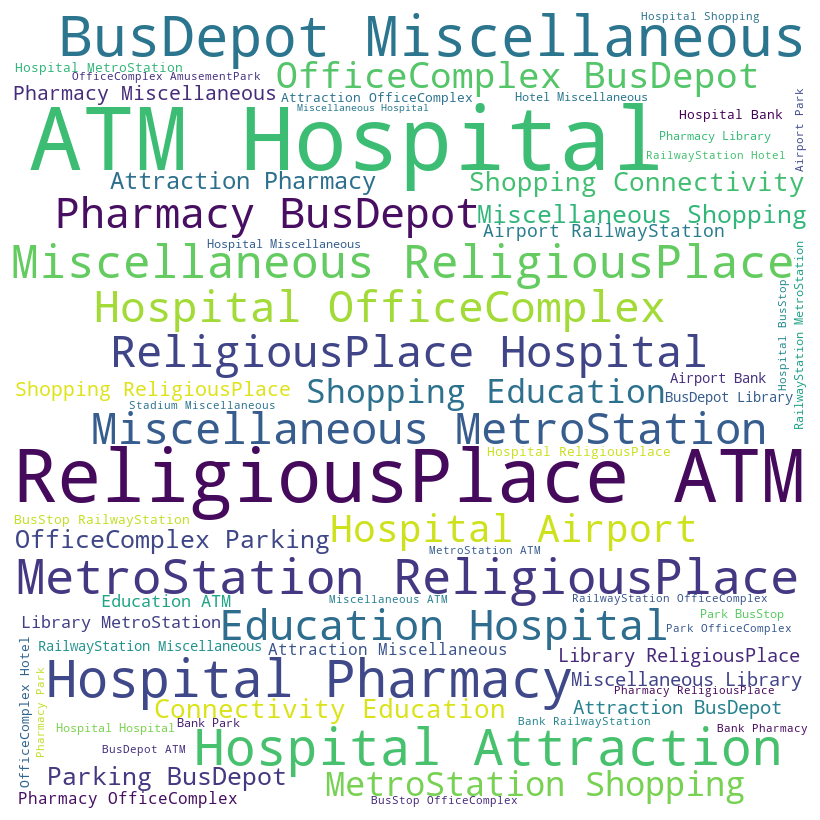

In [71]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, background_color="white", stopwords=set(["s"]), min_font_size=10).generate(details)

plt.figure(figsize = (8,8), facecolor=None)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

In [83]:
import ast

def find_landmark_details(locality):
    main = []
    for item in df1[df1["LOCALITY"] == locality]["LANDMARK_DETAILS"].dropna().apply(ast.literal_eval):
        main.extend(item)

    details = " ".join(main)

    plt.rcParams["font.family"] = "Arial"

    wordcloud = WordCloud(width = 800, height = 800, background_color="white", stopwords=set(["s"]), min_font_size=10).generate(details)

    plt.figure(figsize = (8,8), facecolor=None)
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout(pad = 0)
    plt.show()

In [78]:
df1[df1["LOCALITY"] == "Maheshtala"]["LANDMARK_DETAILS"]

1       ['MetroStation', 'Shopping', 'Connectivity', '...
20                                     ['ReligiousPlace']
49                         ['ReligiousPlace', 'Hospital']
55                         ['ReligiousPlace', 'Hospital']
57                         ['ReligiousPlace', 'Hospital']
176     ['MetroStation', 'Shopping', 'Connectivity', '...
274     ['MetroStation', 'Shopping', 'Connectivity', '...
475     ['MetroStation', 'Shopping', 'Connectivity', '...
481                        ['ReligiousPlace', 'Hospital']
538                        ['ReligiousPlace', 'Hospital']
555                        ['ReligiousPlace', 'Hospital']
793     ['MetroStation', 'Shopping', 'Connectivity', '...
1626                       ['ReligiousPlace', 'Hospital']
3441    ['MetroStation', 'Shopping', 'Connectivity', '...
4073                       ['ReligiousPlace', 'Hospital']
Name: LANDMARK_DETAILS, dtype: str

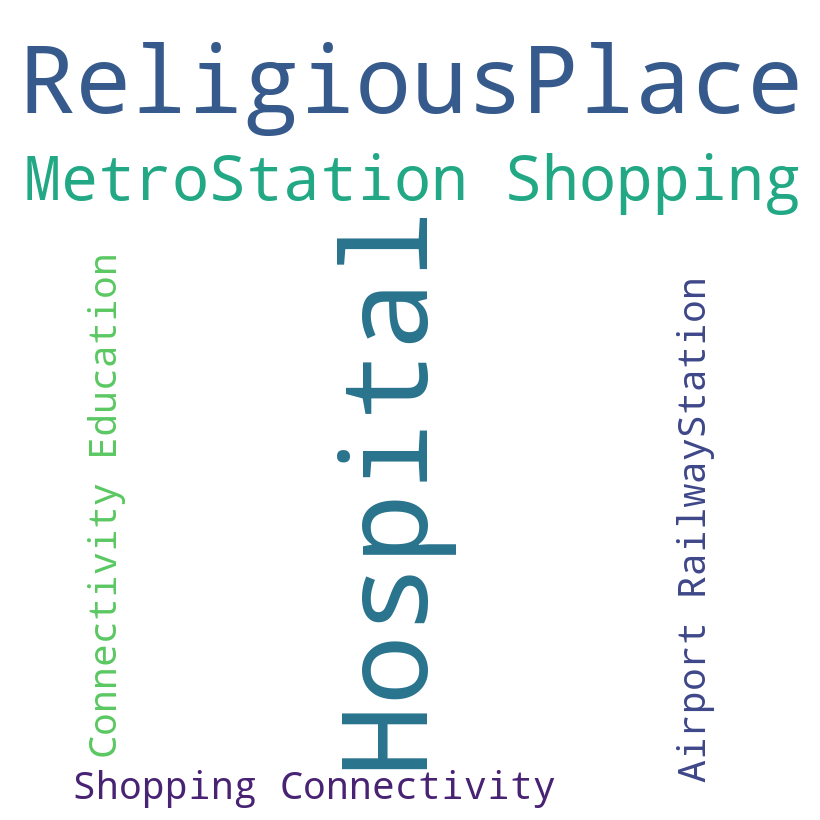

In [84]:
find_landmark_details("Maheshtala")

In [86]:
fig = px.scatter(df, x = "AREA_SQFT", y = "PRICE_Cr", color = "BEDROOM_NUM", title = "Area v/s Price")
fig.show()

In [87]:
fig = px.pie(df, names = "BEDROOM_NUM", title = "Total Bill amount by Day")
fig.show()

In [ ]:
fig = px.box(df[df["BEDROOM_NUM"] <= 4], x = "BEDROOM_NUM", y = "PRICE_Cr", title = "BHK Price Range")
fig.show()

In [90]:
df.head(2)

,PREFERENCE,DESCRIPTION,TRANSACT_TYPE,BEDROOM_NUM,AGE,TOTAL_FLOOR,PROP_NAME,PROP_HEADING,SECONDARY_TAGS,TOTAL_LANDMARK_COUNT,BALCONY_NUM,FLOOR_NUM,PRICE_Cr,AREA_SQFT,PRICE_PER_SQFT(INR),OWNTYPE_label,LATITUDE,LONGITUDE,Cooperative Society,Power of Attorney,Other,Leasehold,FACING_LABEL,FACING_label_North,FACING_label_North-East,FACING_label_North-West,FACING_label_Other,FACING_label_South,FACING_label_South-East,FACING_label_South-West,FACING_label_West,FURNISH_LABEL,FURNISH_label_Other,FURNISH_label_Semi-furnished,FURNISH_label_Unfurnished,PROPERTY_type,PROPERTY_TYPE_Independent/Builder Floor,PROPERTY_TYPE_Residential Apartment,PROPERTY_TYPE_Residential Land,CITY_LABELS,CITY_Kolkata East,CITY_Kolkata North,CITY_Kolkata South,CITY_Kolkata West,LANDMARK_DETAILS,CITY_NUM,LOCALITY
0,S,3bhk flat on the second floor of a four-Storey...,1.0,3.0,6,4.0,team taurus kabya,3 BHK Flat in Rajarhat,"['READY TO MOVE', 'RESALE', 'RERA | HIRA']",29.0,2.0,2.0,0.50,1287.0,3885.00,Cooperative Society,22.629509,88.479623,1,0,0,0,East,0,0,0,0,0,0,0,0,Fully furnished,0,0,0,Residential Apartment,0,1,0,Kolkata East,1,0,0,0,"['ReligiousPlace', 'Hospital', 'OfficeComplex'...",28,Rajarhat
1,S,"3bhk, 2 bath, semi-Furnished, 7th floor (Of 15...",1.0,3.0,2,15.0,eden city maheshtala,3 BHK Flat in Maheshtala,"['READY TO MOVE', 'RESALE', 'RERA | HIRA']",8.0,1.0,7.0,0.45,1377.0,3267.97,Cooperative Society,88.210954,22.493402,1,0,0,0,East,0,0,0,0,0,0,0,0,Other,1,0,0,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['MetroStation', 'Shopping', 'Connectivity', '...",27,Maheshtala


In [91]:
df["OWNTYPE_label"].unique()

<ArrowStringArray>
['Cooperative Society', 'Power of Attorney', 'Other', 'Leasehold']
Length: 4, dtype: str